# Raw line family only experiment

Ten notebook jest calkowicie odseparowany od poprzednich eksperymentow.

Obecna wersja robi:
- wczytanie obrazu,
- grayscale,
- odszumienie,
- binaryzacje,
- cleanup,
- przypisanie surowych segmentow do rodzin `horizontal` i `vertical`,
- budowe wstepnych `LogicalLine`,
- render `raw line families` na `cleanup`,
- repair,
- render wejscia do `pixel connection` razem z prostokatami tolerancji,
- pixel-validated laczenie koncow linii na `repair`,
- przypisanie przeciec miedzy liniami poziomymi i pionowymi,
- trim linii do przeciec i ponowne przeliczenie intersections,
- render retained overlayow rodzin linii, stanow `post_connection`, finalnych linii oraz intersections.

Uwaga:
- prostokaty tolerancji sa dalej uzywane wewnetrznie przez etap connection,
- notebook renderuje teraz tez ich diagnostyczny widok wejsciowy przed samym connection.

Ta wersja nadal nie liczy:
- warp,
- finalnej siatki planszy,
- komorek,
- OCR cyfr.

In [103]:
import bootstrap as bootstrap

In [104]:
import importlib
import sys

bootstrap = importlib.reload(bootstrap)
sys.modules.pop("pipeline", None)
sys.modules.pop("visualization", None)
import pipeline as pipeline
pipeline = importlib.reload(pipeline)
API = bootstrap.load_api()

ExperimentConfig = API.ExperimentConfig
REPO_ROOT = API.REPO_ROOT
RawLineFamilyArtifacts = pipeline.RawLineFamilyArtifacts
build_raw_line_family_plot_items = pipeline.build_raw_line_family_plot_items
configure_manual_image_path = pipeline.configure_manual_image_path
describe_raw_line_family_artifacts = pipeline.describe_raw_line_family_artifacts
resolve_active_image_selection = pipeline.resolve_active_image_selection

print("Reloaded raw line family only API, pipeline, and local modules.")

Reloaded raw line family only API, pipeline, and local modules.


In [105]:
CONFIG = ExperimentConfig(
    raw_hough_threshold=35,
    raw_min_line_length_ratio=0.08,
    raw_max_line_gap_ratio=0.005,
)

print(f"Repo root: {REPO_ROOT}")
print(f"Dataset root: {CONFIG.dataset_root}")
print(
    "Pipeline: "
    f"median_{CONFIG.median_kernel_size} -> "
    "gaussian_block"
    f"{CONFIG.adaptive_threshold_block_size}_c"
    f"{CONFIG.adaptive_threshold_c_value} -> "
    "adaptive_plus_components_soft -> directional_close"
)
print(
    "Tolerance rectangles: "
    f"length={CONFIG.tolerance_rectangle_vector_length_px}, "
    f"padding={CONFIG.tolerance_rectangle_padding_px}"
)

Repo root: /home/wojtek/projects/sudoku
Dataset root: /home/wojtek/projects/sudoku/data/raw/boards
Pipeline: median_5 -> gaussian_block11_c2 -> adaptive_plus_components_soft -> directional_close
Tolerance rectangles: length=350, padding=18


## 1. Wybor obrazka

Mozesz wpisac reczna sciezke albo zostawic puste `IMAGE_PATH_INPUT` i wybrac obraz przez `CONFIG.selected_dataset_index`.

In [106]:
#IMAGE_PATH_INPUT = "/home/wojtek/projects/sudoku/examples/uploads/image1087.jpg"
#IMAGE_PATH_INPUT = "/home/wojtek/projects/sudoku/data/v2_train/image10.jpg"
#IMAGE_PATH_INPUT = "/home/wojtek/projects/sudoku/data/v2_train/image1014.jpg"
#IMAGE_PATH_INPUT = "/home/wojtek/projects/sudoku/data/v1_test/image1004.jpg"
#IMAGE_PATH_INPUT = "/home/wojtek/projects/sudoku/data/v1_training/image1.jpg"
#IMAGE_PATH_INPUT = "/home/wojtek/projects/sudoku/data/RemoveData/image209.jpg"
#IMAGE_PATH_INPUT = "/home/wojtek/projects/sudoku/data/v2_train/image206.jpg"
#IMAGE_PATH_INPUT = "/home/wojtek/projects/sudoku/data/mixed2/image1059.jpg"
#IMAGE_PATH_INPUT = "/home/wojtek/projects/sudoku/data/v2_test/image25.jpg"
#IMAGE_PATH_INPUT = "/home/wojtek/projects/sudoku/data/RemoveData/image1083.jpg"
#IMAGE_PATH_INPUT = "/home/wojtek/projects/sudoku/examples/uploads/image1067.jpg"
#IMAGE_PATH_INPUT = "/home/wojtek/projects/sudoku/data/raw/boards/mixed/image112.jpg"
IMAGE_PATH_INPUT = "/home/wojtek/projects/sudoku/data/examples/uploads/image1067.jpg"
#
# Przyklad:#
# IMAGE_PATH_INPUT = "data/raw/boards/przyklad/board_01.jpg"
# IMAGE_PATH_INPUT = ""7

print(configure_manual_image_path(CONFIG, IMAGE_PATH_INPUT, REPO_ROOT))

Manual image path enabled: /home/wojtek/projects/sudoku/data/examples/uploads/image1067.jpg


In [107]:
IMAGE_SELECTION = resolve_active_image_selection(CONFIG, API)
ACTIVE_IMAGE_PATH = IMAGE_SELECTION.active_image_path

for line in IMAGE_SELECTION.preview_lines:
    print(line)

Found 250 image(s) under dataset root.
[00] mixed/image1.jpg
[01] mixed/image10.jpg
[02] mixed/image100.jpg
[03] mixed/image102.jpg
[04] mixed/image103.jpg
[05] mixed/image104.jpg
[06] mixed/image106.jpg
[07] mixed/image107.jpg
[08] mixed/image109.jpg
[09] mixed/image111.jpg
[10] mixed/image112.jpg
[11] mixed/image113.jpg
[12] mixed/image114.jpg
[13] mixed/image117.jpg
[14] mixed/image118.jpg
[15] mixed/image119.jpg
[16] mixed/image120.jpg
[17] mixed/image122.jpg
[18] mixed/image125.jpg
[19] mixed/image126.jpg
... and 230 more

Active image: /home/wojtek/projects/sudoku/data/examples/uploads/image1067.jpg


In [108]:
import cv2

SOURCE_BGR = API.load_image_bgr(ACTIVE_IMAGE_PATH)
DISPLAY_BGR = API.resize_for_display(SOURCE_BGR, CONFIG.max_display_size)
GRAY_IMAGE = cv2.cvtColor(DISPLAY_BGR, cv2.COLOR_BGR2GRAY)

DENOISE_NAME = f"median_{CONFIG.median_kernel_size}"
DENOISED_IMAGE = API.apply_median_denoise(
    GRAY_IMAGE,
    CONFIG,
)

THRESHOLD_NAME = (
    "gaussian_block"
    f"{CONFIG.adaptive_threshold_block_size}_c{CONFIG.adaptive_threshold_c_value}"
)
BINARY_IMAGE = API.apply_gaussian_threshold(
    DENOISED_IMAGE,
    CONFIG,
)

CLEANUP_NAME = "adaptive_plus_components_soft"
MIN_COMPONENT_AREA_PX, CLEAN_BINARY = API.apply_soft_component_cleanup(
    BINARY_IMAGE,
    CONFIG,
)

FAMILY_DETECTION_RESULT = API.detect_line_families(
    CLEAN_BINARY,
    CONFIG,
    include_logical_lines=False,
)
CLEANUP_BINARY_FAMILY_OVERLAY, SOURCE_FAMILY_OVERLAY = API.build_line_family_overlays(
    DISPLAY_BGR,
    CLEAN_BINARY,
    FAMILY_DETECTION_RESULT,
    CONFIG,
)


Repair time: 0.006s
Detect + logical lines + pixel connection time with Hough only on cleanup and pixels on repair: 11.815s
Pixel render binary: repair binary used for pixel connection

Original shape: (1182, 960, 3)
Display shape:  (1182, 960, 3)
Denoise: median_5
Threshold: gaussian_block11_c2
Cleanup: adaptive_plus_components_soft
Repair: directional_close
Connected components min area px: 74
Raw Hough segments: 212
Orientation offset degrees: -1.1294553284816402
Horizontal family segments: 116
Vertical family segments: 96
Horizontal final logical lines: 29
Vertical final logical lines: 20
Horizontal same-axis connection segments: 0
Vertical same-axis connection segments: 0
Horizontal cross-axis connection segments: 0
Vertical cross-axis connection segments: 0
Logical line intersections: 187
Cross intersections: 148
Touch intersections: 39
Boundary intersections: 40
Start intersections: 20
Middle intersections: 147
End intersections: 20
Both intersections: 0
Logical line frames: 5
S

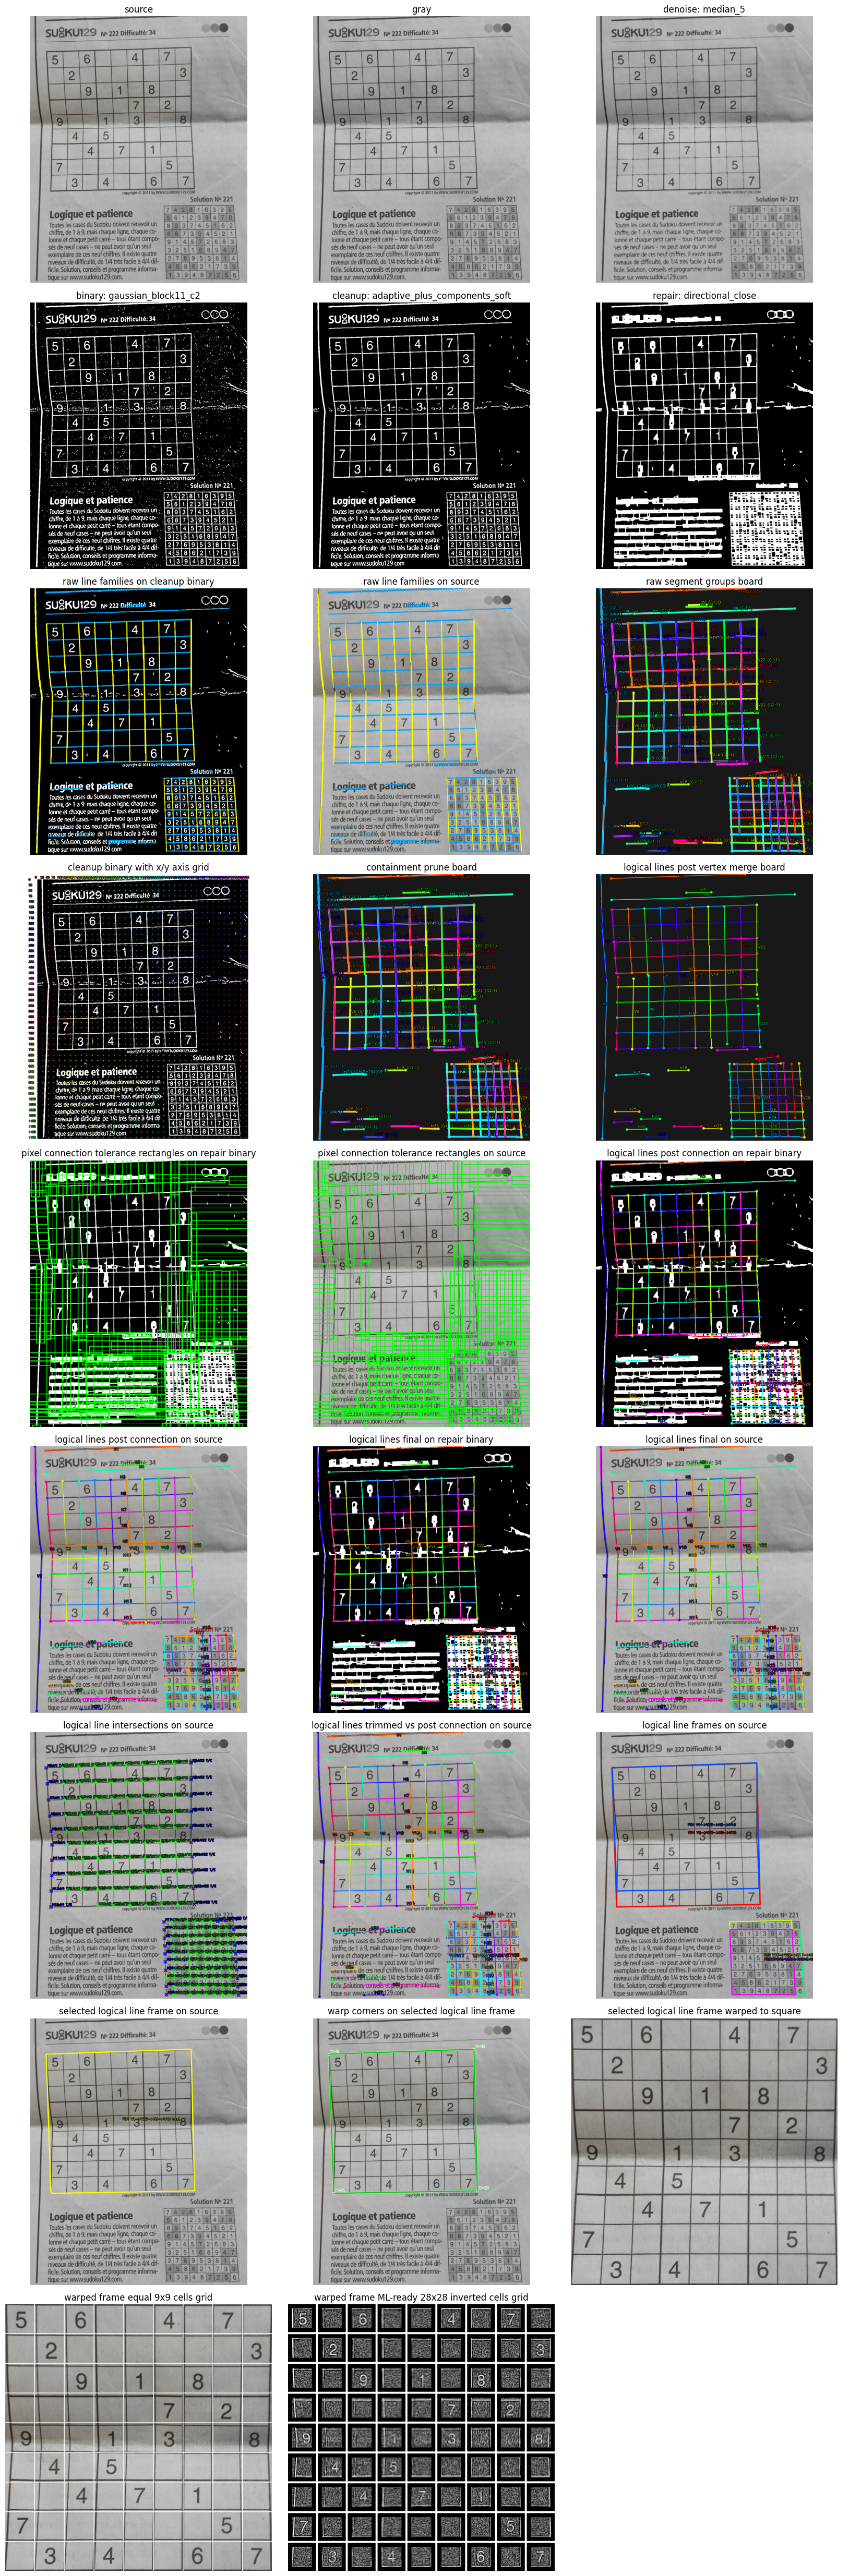

In [109]:
import time

REPAIR_NAME = "directional_close"
repair_started_at = time.perf_counter()
REPAIRED_BINARY = API.apply_directional_close_repair(
    CLEAN_BINARY,
    CONFIG,
)
repair_elapsed_s = time.perf_counter() - repair_started_at

PIXEL_CONNECTION_BINARY_NAME = "repair"
# Do testu mozna przelaczyc na:
# PIXEL_CONNECTION_BINARY_NAME = "cleanup"

if PIXEL_CONNECTION_BINARY_NAME == "cleanup":
    PIXEL_CONNECTION_BINARY = CLEAN_BINARY
elif PIXEL_CONNECTION_BINARY_NAME == "repair":
    PIXEL_CONNECTION_BINARY = REPAIRED_BINARY
else:
    raise ValueError(
        "PIXEL_CONNECTION_BINARY_NAME must be 'cleanup' or 'repair'."
    )

full_detection_started_at = time.perf_counter()
FINAL_LINE_FAMILY_RESULT = API.detect_line_families(
    CLEAN_BINARY,
    CONFIG,
    pixel_connection_binary_image=PIXEL_CONNECTION_BINARY,
    warp_source_image=DISPLAY_BGR,
)
full_detection_elapsed_s = time.perf_counter() - full_detection_started_at

PIXEL_RENDER_BINARY_NAME = (
    f"{PIXEL_CONNECTION_BINARY_NAME} binary used for pixel connection"
)
RAW_SEGMENT_GROUP_BOARD = API.build_raw_segment_group_board(
    DISPLAY_BGR,
    FINAL_LINE_FAMILY_RESULT,
    CONFIG,
)
CONTAINMENT_PRUNE_BOARD = API.build_containment_prune_board(
    DISPLAY_BGR,
    FINAL_LINE_FAMILY_RESULT,
    CONFIG,
)
VERTEX_CONTAINMENT_MERGE_BOARD = API.build_vertex_containment_merge_board(
    DISPLAY_BGR,
    FINAL_LINE_FAMILY_RESULT,
    CONFIG,
)
(
    BINARY_CONNECTION_INPUT_OVERLAY,
    SOURCE_CONNECTION_INPUT_OVERLAY,
) = API.build_connection_input_logical_line_overlays(
    DISPLAY_BGR,
    PIXEL_CONNECTION_BINARY,
    FINAL_LINE_FAMILY_RESULT,
    CONFIG,
)
(
    BINARY_POST_CONNECTION_LOGICAL_LINE_OVERLAY,
    SOURCE_POST_CONNECTION_LOGICAL_LINE_OVERLAY,
) = API.build_post_connection_logical_line_overlays(
    DISPLAY_BGR,
    PIXEL_CONNECTION_BINARY,
    FINAL_LINE_FAMILY_RESULT,
    CONFIG,
)
BINARY_LOGICAL_LINE_OVERLAY, SOURCE_LOGICAL_LINE_OVERLAY = API.build_logical_line_overlays(
    DISPLAY_BGR,
    PIXEL_CONNECTION_BINARY,
    FINAL_LINE_FAMILY_RESULT,
    CONFIG,
)
SOURCE_TRIMMED_LOGICAL_LINE_OVERLAY = API.build_trimmed_logical_line_overlays(
    DISPLAY_BGR,
    PIXEL_CONNECTION_BINARY,
    FINAL_LINE_FAMILY_RESULT,
    CONFIG,
)
SOURCE_LOGICAL_LINE_INTERSECTION_OVERLAY = API.build_logical_line_intersection_overlays(
    DISPLAY_BGR,
    PIXEL_CONNECTION_BINARY,
    FINAL_LINE_FAMILY_RESULT,
    CONFIG,
)
SOURCE_LOGICAL_LINE_FRAME_OVERLAY = API.build_logical_line_frame_overlay(
    DISPLAY_BGR,
    PIXEL_CONNECTION_BINARY,
    FINAL_LINE_FAMILY_RESULT,
    CONFIG,
)
SOURCE_SELECTED_LOGICAL_LINE_FRAME_OVERLAY = (
    API.build_selected_logical_line_frame_overlay(
        DISPLAY_BGR,
        PIXEL_CONNECTION_BINARY,
        FINAL_LINE_FAMILY_RESULT,
        CONFIG,
    )
)
SOURCE_SELECTED_FRAME_WARP_OVERLAY = API.build_selected_frame_warp_overlay(
    DISPLAY_BGR,
    PIXEL_CONNECTION_BINARY,
    FINAL_LINE_FAMILY_RESULT,
    CONFIG,
)
SELECTED_FRAME_SQUARE_WARP = None
if FINAL_LINE_FAMILY_RESULT.selected_logical_line_frame_warp_result is not None:
    SELECTED_FRAME_SQUARE_WARP = (
        FINAL_LINE_FAMILY_RESULT.selected_logical_line_frame_warp_result.warped_image
    )
CLEAN_BINARY_AXIS_OVERLAY = API.build_clean_binary_axis_overlay(
    CLEAN_BINARY,
    CONFIG,
)

ARTIFACTS = RawLineFamilyArtifacts(
    source_bgr=SOURCE_BGR,
    display_bgr=DISPLAY_BGR,
    gray_image=GRAY_IMAGE,
    denoise_name=DENOISE_NAME,
    denoised_image=DENOISED_IMAGE,
    threshold_name=THRESHOLD_NAME,
    binary_image=BINARY_IMAGE,
    min_component_area_px=MIN_COMPONENT_AREA_PX,
    cleanup_name=CLEANUP_NAME,
    clean_binary=CLEAN_BINARY,
    clean_binary_axis_overlay=CLEAN_BINARY_AXIS_OVERLAY,
    repair_name=REPAIR_NAME,
    repaired_binary=REPAIRED_BINARY,
    line_family_result=FINAL_LINE_FAMILY_RESULT,
    binary_family_overlay=CLEANUP_BINARY_FAMILY_OVERLAY,
    source_family_overlay=SOURCE_FAMILY_OVERLAY,
    raw_segment_group_board=RAW_SEGMENT_GROUP_BOARD,
    containment_prune_board=CONTAINMENT_PRUNE_BOARD,
    vertex_containment_merge_board=VERTEX_CONTAINMENT_MERGE_BOARD,
    binary_connection_input_overlay=BINARY_CONNECTION_INPUT_OVERLAY,
    source_connection_input_overlay=SOURCE_CONNECTION_INPUT_OVERLAY,
    binary_post_connection_logical_line_overlay=(
        BINARY_POST_CONNECTION_LOGICAL_LINE_OVERLAY
    ),
    source_post_connection_logical_line_overlay=(
        SOURCE_POST_CONNECTION_LOGICAL_LINE_OVERLAY
    ),
    binary_logical_line_overlay=BINARY_LOGICAL_LINE_OVERLAY,
    source_logical_line_overlay=SOURCE_LOGICAL_LINE_OVERLAY,
    source_trimmed_logical_line_overlay=(
        SOURCE_TRIMMED_LOGICAL_LINE_OVERLAY
    ),
    source_logical_line_intersection_overlay=(
        SOURCE_LOGICAL_LINE_INTERSECTION_OVERLAY
    ),
    source_logical_line_frame_overlay=(
        SOURCE_LOGICAL_LINE_FRAME_OVERLAY
    ),
    source_selected_logical_line_frame_overlay=(
        SOURCE_SELECTED_LOGICAL_LINE_FRAME_OVERLAY
    ),
    source_selected_frame_warp_overlay=(
        SOURCE_SELECTED_FRAME_WARP_OVERLAY
    ),
    selected_frame_square_warp=SELECTED_FRAME_SQUARE_WARP,
)

print(f"Repair time: {repair_elapsed_s:.3f}s")
print(
    "Detect + logical lines + pixel connection time "
    f"with Hough only on cleanup and pixels on {PIXEL_CONNECTION_BINARY_NAME}: "
    f"{full_detection_elapsed_s:.3f}s"
)
print(f"Pixel render binary: {PIXEL_RENDER_BINARY_NAME}")
print()

for line in describe_raw_line_family_artifacts(ARTIFACTS):
    print(line)

API.plot_named_images(
    build_raw_line_family_plot_items(ARTIFACTS),
    columns=3,
    figure_scale=5.5,
)

## 2. Diagnostyka pustego pola dla wybranej komorki 9x9

Nowy etap dziala na **surowej komorce wycietej z warped board**.

Kolejnosc:
1. Numerujemy komorki planszy `1..81` od lewej do prawej i od gory do dolu.
2. Wybieramy jedna komorke po numerze.
3. Bierzemy jej surowy obraz `BGR` z siatki `9x9`.
4. Dopiero potem robimy grayscale i binaryzacje.
5. Wycinamy centralny obszar przez skladanie wybranych "cwiartek z cwiartek".
6. Na tym obrazie uruchamiamy Hough, odrzucamy za krotkie segmenty i liczymy piksele foreground.
7. Jesli foreground przekracza prog, traktujemy pole jako cyfre; w przeciwnym razie jako puste.

In [110]:
from search_empty_cell import (
    EmptyCellConfig,
    analyze_raw_cell_bgr,
    analyze_raw_cells_grid,
    build_empty_cell_processing_config,
    draw_numbered_board_overlay,
    draw_status_board_overlay,
    render_segments_overlay,
    resolve_cell_position,
)


EMPTY_CELL_CONFIG = EmptyCellConfig(
    median_kernel_size=CONFIG.median_kernel_size,
    adaptive_block_size=CONFIG.adaptive_threshold_block_size,
    adaptive_c=CONFIG.adaptive_threshold_c_value,
    binary_min_component_area_ratio=CONFIG.binary_min_component_area_ratio,
    binary_min_component_area_floor_px=CONFIG.binary_min_component_area_floor_px,
    soft_cleanup_area_multiplier=CONFIG.soft_cleanup_area_multiplier,
    inner_margin_ratio=0.0,
    hough_threshold=8,
    hough_min_line_length_ratio=0.20,
    hough_max_line_gap_ratio=0.10,
    min_segment_length_px=15,
    filtered_segment_count_threshold=5,
    pixel_ratio_threshold=0.15,
    pixel_count_threshold=None,
    decision_mode="pixels_or_segments",
)
EMPTY_CELL_CELL_NUMBER_1_BASED = 38
EMPTY_CELL_PROCESSING_CONFIG = build_empty_cell_processing_config(
    CONFIG,
    EMPTY_CELL_CONFIG,
)










Selected cell: number=38, row=4, col=1
Raw cell shape: (80, 80, 3)


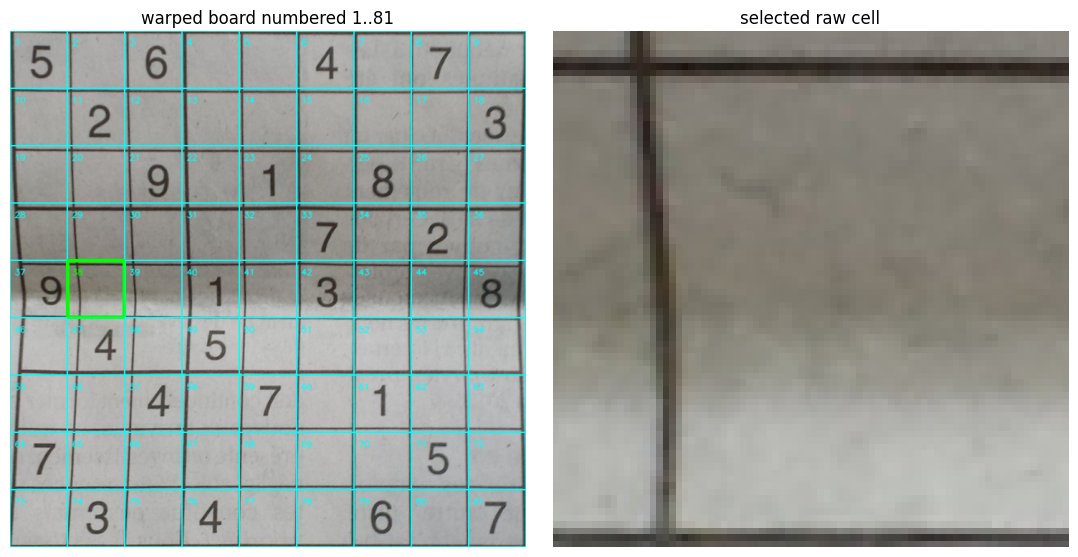

In [111]:
EMPTY_CELL_WARP_RESULT = FINAL_LINE_FAMILY_RESULT.selected_logical_line_frame_warp_result
if EMPTY_CELL_WARP_RESULT is None:
    raise ValueError("Selected logical line frame warp result is unavailable.")

EMPTY_CELL_GRID_RESULT = EMPTY_CELL_WARP_RESULT.cells_grid_result
if EMPTY_CELL_GRID_RESULT is None:
    raise ValueError("Cells grid result is unavailable.")

EMPTY_CELL_ROW_INDEX, EMPTY_CELL_COL_INDEX = resolve_cell_position(
    EMPTY_CELL_CELL_NUMBER_1_BASED,
)
EMPTY_CELL_RAW_BGR = EMPTY_CELL_GRID_RESULT.cells[EMPTY_CELL_ROW_INDEX][
    EMPTY_CELL_COL_INDEX
]
EMPTY_CELL_NUMBERED_BOARD_OVERLAY = draw_numbered_board_overlay(
    EMPTY_CELL_WARP_RESULT.warped_image,
    EMPTY_CELL_CELL_NUMBER_1_BASED,
)

print(
    "Selected cell: "
    f"number={EMPTY_CELL_CELL_NUMBER_1_BASED}, "
    f"row={EMPTY_CELL_ROW_INDEX}, col={EMPTY_CELL_COL_INDEX}"
)
print(f"Raw cell shape: {EMPTY_CELL_RAW_BGR.shape}")

API.plot_named_images(
    [
        ("warped board numbered 1..81", EMPTY_CELL_NUMBERED_BOARD_OVERLAY, True),
        ("selected raw cell", EMPTY_CELL_RAW_BGR, True),
    ],
    columns=2,
    figure_scale=5.5,
)

Cell preprocessing config: median_kernel_size=5, block_size=11, adaptive_c=2, soft_cleanup_area_multiplier=0.35, inner_margin_ratio=0.0
Cell cleanup thresholds: binary_min_component_area_ratio=8e-05, binary_min_component_area_floor_px=16, resolved_min_component_area_px=16
Binary mask shape: (80, 80)
Clean mask shape: (80, 80)
Center composite shape: (40, 40)


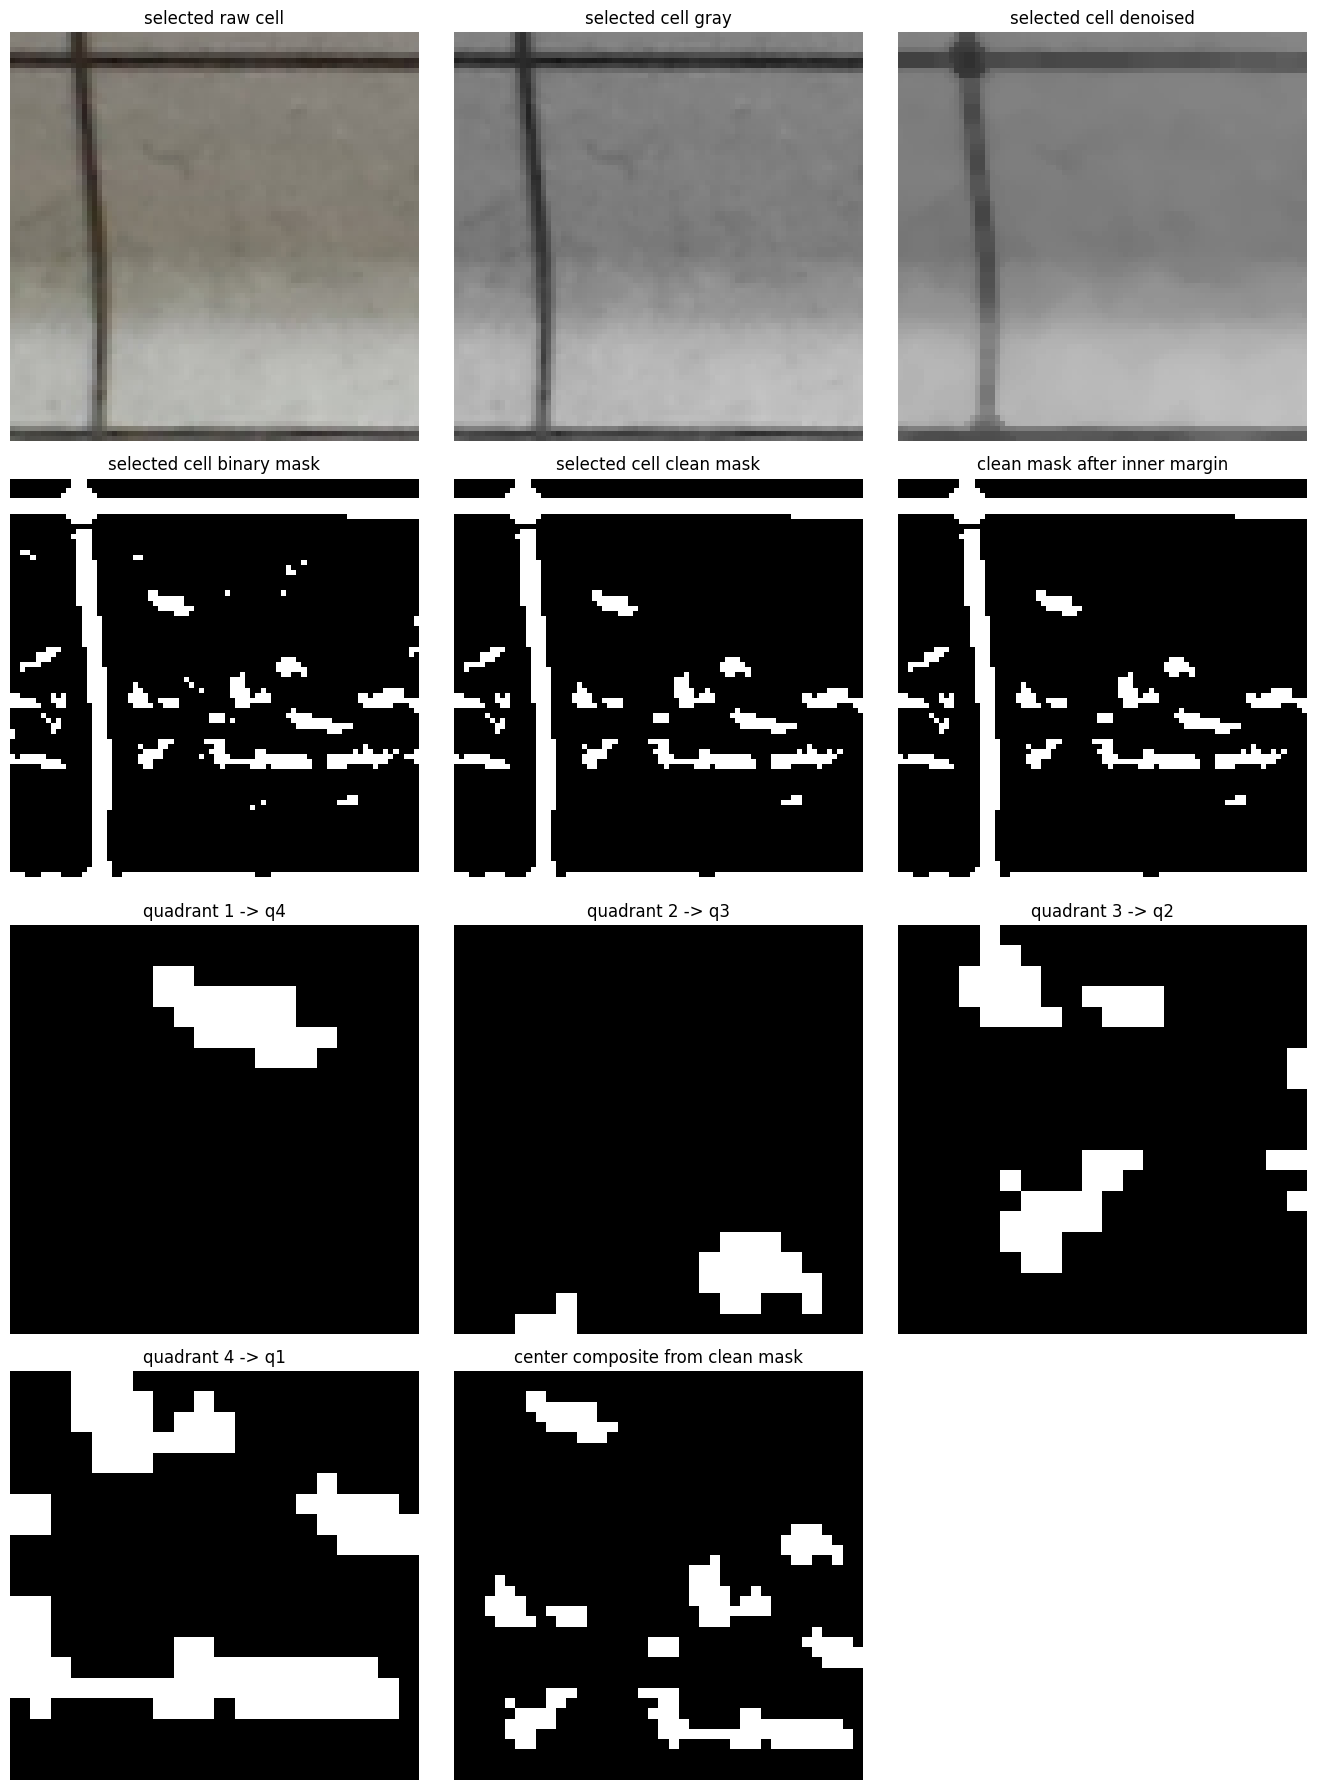

In [112]:
EMPTY_CELL_ANALYSIS = analyze_raw_cell_bgr(
    EMPTY_CELL_RAW_BGR,
    empty_cell_config=EMPTY_CELL_CONFIG,
    processing_config=EMPTY_CELL_PROCESSING_CONFIG,
)
EMPTY_CELL_GRAY = EMPTY_CELL_ANALYSIS.preprocessing.gray_image
EMPTY_CELL_DENOISED = EMPTY_CELL_ANALYSIS.preprocessing.denoised_image
EMPTY_CELL_BINARY_MASK = EMPTY_CELL_ANALYSIS.preprocessing.binary_mask
EMPTY_CELL_MIN_COMPONENT_AREA_PX = (
    EMPTY_CELL_ANALYSIS.preprocessing.min_component_area_px
)
EMPTY_CELL_CLEAN_MASK = EMPTY_CELL_ANALYSIS.preprocessing.clean_mask
EMPTY_CELL_CLEAN_MASK_INNER = EMPTY_CELL_ANALYSIS.preprocessing.clean_mask_inner
EMPTY_CELL_SELECTED_QUADRANTS = EMPTY_CELL_ANALYSIS.preprocessing.selected_quadrants
EMPTY_CELL_CENTER_COMPOSITE = EMPTY_CELL_ANALYSIS.preprocessing.center_composite

print(
    "Cell preprocessing config: "
    f"median_kernel_size={EMPTY_CELL_CONFIG.median_kernel_size}, "
    f"block_size={EMPTY_CELL_CONFIG.adaptive_block_size}, "
    f"adaptive_c={EMPTY_CELL_CONFIG.adaptive_c}, "
    f"soft_cleanup_area_multiplier={EMPTY_CELL_CONFIG.soft_cleanup_area_multiplier}, "
    f"inner_margin_ratio={EMPTY_CELL_CONFIG.inner_margin_ratio}"
)
print(
    "Cell cleanup thresholds: "
    f"binary_min_component_area_ratio={EMPTY_CELL_CONFIG.binary_min_component_area_ratio}, "
    f"binary_min_component_area_floor_px={EMPTY_CELL_CONFIG.binary_min_component_area_floor_px}, "
    f"resolved_min_component_area_px={EMPTY_CELL_MIN_COMPONENT_AREA_PX}"
)
print(f"Binary mask shape: {EMPTY_CELL_BINARY_MASK.shape}")
print(f"Clean mask shape: {EMPTY_CELL_CLEAN_MASK.shape}")
print(f"Center composite shape: {EMPTY_CELL_CENTER_COMPOSITE.shape}")

API.plot_named_images(
    [
        ("selected raw cell", EMPTY_CELL_RAW_BGR, True),
        ("selected cell gray", EMPTY_CELL_GRAY, False),
        ("selected cell denoised", EMPTY_CELL_DENOISED, False),
        ("selected cell binary mask", EMPTY_CELL_BINARY_MASK, False),
        ("selected cell clean mask", EMPTY_CELL_CLEAN_MASK, False),
        ("clean mask after inner margin", EMPTY_CELL_CLEAN_MASK_INNER, False),
        ("quadrant 1 -> q4", EMPTY_CELL_SELECTED_QUADRANTS["1_q4"], False),
        ("quadrant 2 -> q3", EMPTY_CELL_SELECTED_QUADRANTS["2_q3"], False),
        ("quadrant 3 -> q2", EMPTY_CELL_SELECTED_QUADRANTS["3_q2"], False),
        ("quadrant 4 -> q1", EMPTY_CELL_SELECTED_QUADRANTS["4_q1"], False),
        ("center composite from clean mask", EMPTY_CELL_CENTER_COMPOSITE, False),
    ],
    columns=3,
    figure_scale=4.5,
)

Hough on clean composite: threshold=8, min_line_length_ratio=0.2, max_line_gap_ratio=0.1, min_segment_length_px=15
Detected Hough segments: 6
Filtered Hough segments: 2
Filtered segment threshold: 5
Foreground pixel count on clean composite: 189
Foreground pixel ratio on clean composite: 0.118125
Pixel ratio threshold: 0.150000
Decision mode: pixels_or_segments
Decision rule: non-empty when pixel rule passes OR segment rule passes. Segment rule threshold=5, pixel ratio threshold=0.150000.
Accept by pixels: False
Accept by segments: False
Accept as digit: False
Treat as empty: True


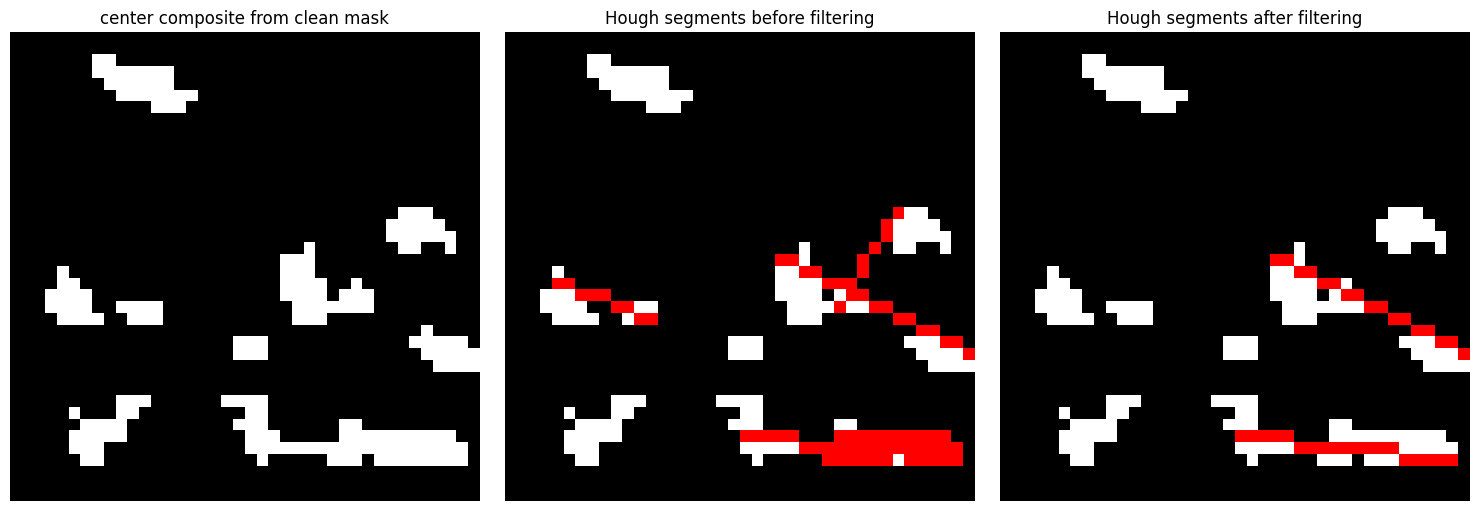

In [113]:
EMPTY_CELL_HOUGH_SEGMENTS = EMPTY_CELL_ANALYSIS.hough_segments
EMPTY_CELL_FILTERED_SEGMENTS = EMPTY_CELL_ANALYSIS.filtered_segments
EMPTY_CELL_HOUGH_OVERLAY_ALL = render_segments_overlay(
    EMPTY_CELL_CENTER_COMPOSITE,
    EMPTY_CELL_HOUGH_SEGMENTS,
)
EMPTY_CELL_HOUGH_OVERLAY_FILTERED = render_segments_overlay(
    EMPTY_CELL_CENTER_COMPOSITE,
    EMPTY_CELL_FILTERED_SEGMENTS,
)
EMPTY_CELL_FOREGROUND_PIXEL_COUNT = EMPTY_CELL_ANALYSIS.foreground_pixel_count
EMPTY_CELL_FOREGROUND_PIXEL_RATIO = EMPTY_CELL_ANALYSIS.foreground_pixel_ratio
EMPTY_CELL_SEGMENT_COUNT = EMPTY_CELL_ANALYSIS.filtered_segment_count
EMPTY_CELL_ACCEPT_BY_PIXELS = EMPTY_CELL_ANALYSIS.accept_by_pixels
EMPTY_CELL_ACCEPT_BY_SEGMENTS = EMPTY_CELL_ANALYSIS.accept_by_segments
EMPTY_CELL_ACCEPT_AS_DIGIT = EMPTY_CELL_ANALYSIS.accept_as_digit

print(
    "Hough on clean composite: "
    f"threshold={EMPTY_CELL_CONFIG.hough_threshold}, "
    f"min_line_length_ratio={EMPTY_CELL_CONFIG.hough_min_line_length_ratio}, "
    f"max_line_gap_ratio={EMPTY_CELL_CONFIG.hough_max_line_gap_ratio}, "
    f"min_segment_length_px={EMPTY_CELL_CONFIG.min_segment_length_px}"
)
print(f"Detected Hough segments: {len(EMPTY_CELL_HOUGH_SEGMENTS)}")
print(f"Filtered Hough segments: {EMPTY_CELL_SEGMENT_COUNT}")
print(
    "Filtered segment threshold: "
    f"{EMPTY_CELL_CONFIG.filtered_segment_count_threshold}"
)
print(f"Foreground pixel count on clean composite: {EMPTY_CELL_FOREGROUND_PIXEL_COUNT}")
print(f"Foreground pixel ratio on clean composite: {EMPTY_CELL_FOREGROUND_PIXEL_RATIO:.6f}")
print(f"Pixel ratio threshold: {EMPTY_CELL_CONFIG.pixel_ratio_threshold:.6f}")
if EMPTY_CELL_CONFIG.pixel_count_threshold is not None:
    print(f"Pixel count threshold: {EMPTY_CELL_CONFIG.pixel_count_threshold}")
print(f"Decision mode: {EMPTY_CELL_CONFIG.decision_mode}")
if EMPTY_CELL_CONFIG.decision_mode == "pixels":
    print(
        "Decision rule: pixel_ratio must be above pixel_ratio_threshold"
        " and, if configured, pixel_count must be above pixel_count_threshold."
    )
elif EMPTY_CELL_CONFIG.decision_mode == "segments":
    print(
        "Decision rule: filtered_segment_count must be greater than or equal to "
        f"{EMPTY_CELL_CONFIG.filtered_segment_count_threshold}."
    )
elif EMPTY_CELL_CONFIG.decision_mode == "pixels_or_segments":
    print(
        "Decision rule: non-empty when pixel rule passes OR segment rule passes. "
        f"Segment rule threshold={EMPTY_CELL_CONFIG.filtered_segment_count_threshold}, "
        f"pixel ratio threshold={EMPTY_CELL_CONFIG.pixel_ratio_threshold:.6f}."
    )
elif EMPTY_CELL_CONFIG.decision_mode == "pixels_and_segments":
    print(
        "Decision rule: non-empty only when pixel rule passes AND segment rule passes. "
        f"Segment rule threshold={EMPTY_CELL_CONFIG.filtered_segment_count_threshold}, "
        f"pixel ratio threshold={EMPTY_CELL_CONFIG.pixel_ratio_threshold:.6f}."
    )
print(f"Accept by pixels: {EMPTY_CELL_ACCEPT_BY_PIXELS}")
print(f"Accept by segments: {EMPTY_CELL_ACCEPT_BY_SEGMENTS}")
print(f"Accept as digit: {EMPTY_CELL_ACCEPT_AS_DIGIT}")
print(f"Treat as empty: {not EMPTY_CELL_ACCEPT_AS_DIGIT}")

API.plot_named_images(
    [
        ("center composite from clean mask", EMPTY_CELL_CENTER_COMPOSITE, False),
        ("Hough segments before filtering", EMPTY_CELL_HOUGH_OVERLAY_ALL, True),
        ("Hough segments after filtering", EMPTY_CELL_HOUGH_OVERLAY_FILTERED, True),
    ],
    columns=3,
    figure_scale=5.0,
)

## 3. Analiza pustych pol dla calej siatki 9x9

Ten etap korzysta juz z funkcji z `search_empty_cell`:
- preprocessing kazdej raw komorki idzie przez wydzielony modul,
- preview `binary`, `clean` i `center composite` sa budowane z wynikow modulu,
- decyzja `puste` / `niepuste` jest liczona w jednej wspolnej logice,
- notebook zostaje tylko cienka warstwa diagnostyczna.

Analysed cells: 81
Empty cells: 55
Non-empty cells: 26
Decision mode: pixels_or_segments
Pixel ratio threshold: 0.150000
Filtered segment threshold: 5
Rule: cell is non-empty when pixel rule passes OR segment rule passes.

cell=01 row=0 col=0 status=niepuste pixels=475 ratio=0.296875 hough=17 filtered=12 acceptByPixels=True acceptBySegments=True
cell=02 row=0 col=1 status=puste pixels=2 ratio=0.001250 hough=0 filtered=0 acceptByPixels=False acceptBySegments=False
cell=03 row=0 col=2 status=niepuste pixels=530 ratio=0.331250 hough=28 filtered=16 acceptByPixels=True acceptBySegments=True
cell=04 row=0 col=3 status=puste pixels=4 ratio=0.002500 hough=0 filtered=0 acceptByPixels=False acceptBySegments=False
cell=05 row=0 col=4 status=puste pixels=9 ratio=0.005625 hough=0 filtered=0 acceptByPixels=False acceptBySegments=False
cell=06 row=0 col=5 status=niepuste pixels=466 ratio=0.291250 hough=16 filtered=13 acceptByPixels=True acceptBySegments=True
cell=07 row=0 col=6 status=puste pixels=47

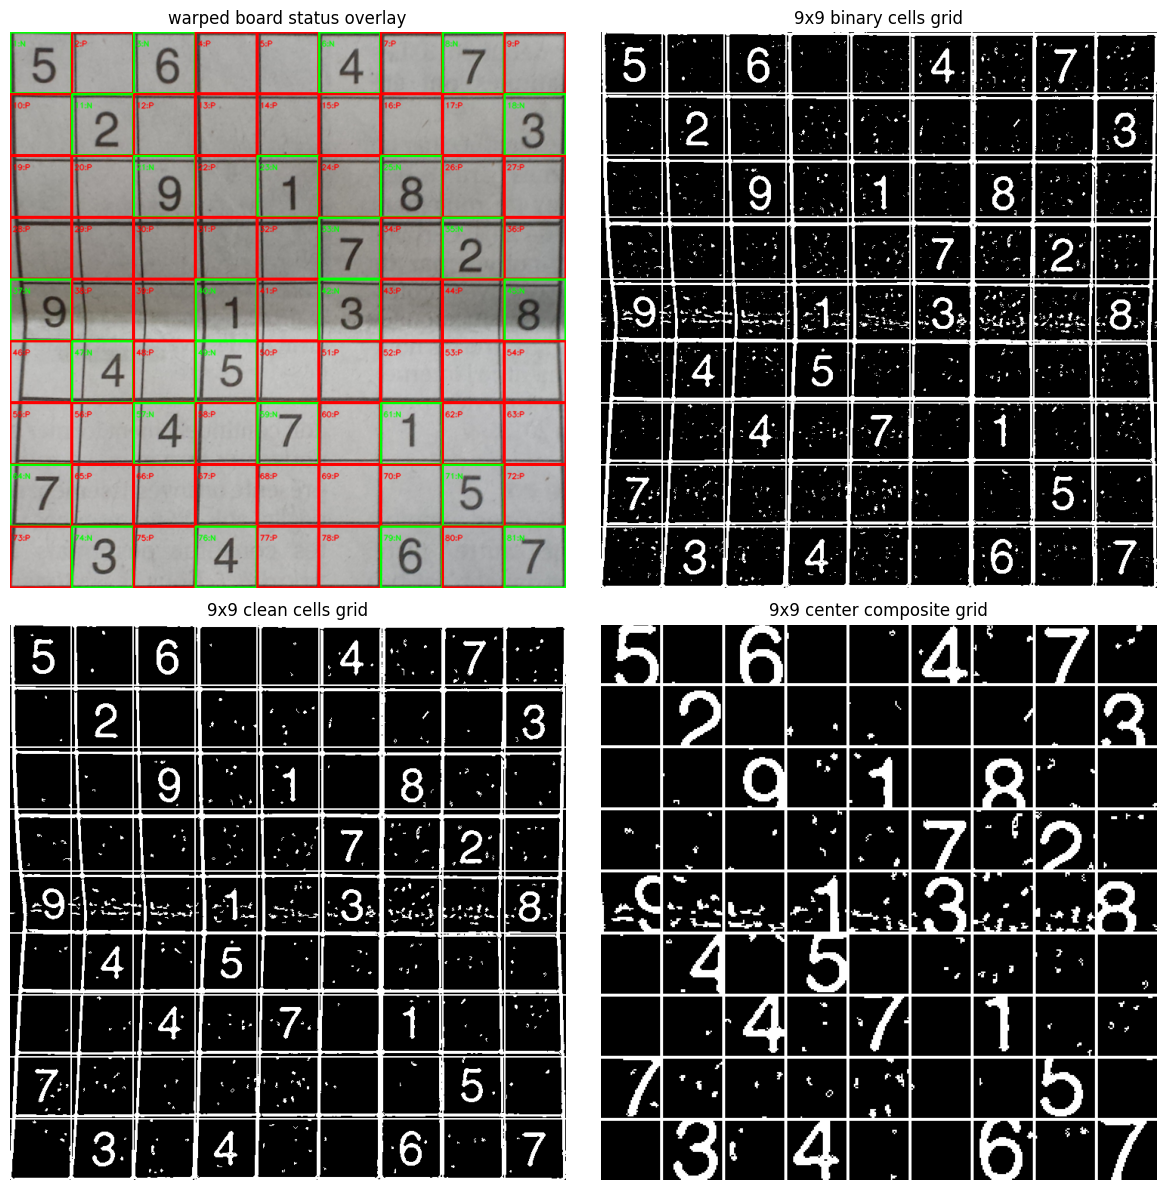

In [114]:
EMPTY_CELL_GRID_ANALYSIS = analyze_raw_cells_grid(
    EMPTY_CELL_GRID_RESULT.cells,
    empty_cell_config=EMPTY_CELL_CONFIG,
    processing_config=EMPTY_CELL_PROCESSING_CONFIG,
    preview_gap_px=CONFIG.warp_cells_preview_gap_px,
)
ALL_CELLS_STATUS_OVERLAY = draw_status_board_overlay(
    EMPTY_CELL_WARP_RESULT.warped_image,
    EMPTY_CELL_GRID_ANALYSIS.cell_results,
)
ALL_CELLS_EMPTY_COUNT = EMPTY_CELL_GRID_ANALYSIS.empty_count
ALL_CELLS_NON_EMPTY_COUNT = EMPTY_CELL_GRID_ANALYSIS.non_empty_count
ALL_CELLS_BINARY_PREVIEW = (
    EMPTY_CELL_GRID_ANALYSIS.preprocessing_result.binary_preview_image
)
ALL_CELLS_CLEAN_MASK_PREVIEW = (
    EMPTY_CELL_GRID_ANALYSIS.preprocessing_result.clean_preview_image
)
ALL_CELLS_CENTER_COMPOSITE_PREVIEW = (
    EMPTY_CELL_GRID_ANALYSIS.preprocessing_result.center_composite_preview_image
)

print(f"Analysed cells: {len(EMPTY_CELL_GRID_ANALYSIS.cell_results)}")
print(f"Empty cells: {ALL_CELLS_EMPTY_COUNT}")
print(f"Non-empty cells: {ALL_CELLS_NON_EMPTY_COUNT}")
print(f"Decision mode: {EMPTY_CELL_CONFIG.decision_mode}")
print(
    f"Pixel ratio threshold: {EMPTY_CELL_CONFIG.pixel_ratio_threshold:.6f}"
)
print(
    "Filtered segment threshold: "
    f"{EMPTY_CELL_CONFIG.filtered_segment_count_threshold}"
)
print(
    "Rule: cell is non-empty when pixel rule passes OR segment rule passes."
    if EMPTY_CELL_CONFIG.decision_mode == "pixels_or_segments"
    else "Rule depends on decision_mode configured above."
)
print()

for cell_result in EMPTY_CELL_GRID_ANALYSIS.cell_results:
    analysis = cell_result.analysis
    status_label = "puste" if analysis.is_empty else "niepuste"
    print(
        f"cell={cell_result.cell_number:02d} "
        f"row={cell_result.row_index} col={cell_result.col_index} "
        f"status={status_label} "
        f"pixels={analysis.foreground_pixel_count} "
        f"ratio={analysis.foreground_pixel_ratio:.6f} "
        f"hough={len(analysis.hough_segments)} "
        f"filtered={analysis.filtered_segment_count} "
        f"acceptByPixels={analysis.accept_by_pixels} "
        f"acceptBySegments={analysis.accept_by_segments}"
    )

API.plot_named_images(
    [
        ("warped board status overlay", ALL_CELLS_STATUS_OVERLAY, True),
        ("9x9 binary cells grid", ALL_CELLS_BINARY_PREVIEW, False),
        ("9x9 clean cells grid", ALL_CELLS_CLEAN_MASK_PREVIEW, False),
        ("9x9 center composite grid", ALL_CELLS_CENTER_COMPOSITE_PREVIEW, False),
    ],
    columns=2,
    figure_scale=6.0,
)




## 4. Uwaga

Diagnostyka pustego pola powyzej korzysta juz bezposrednio z modulu `search_empty_cell`, wiec nie utrzymujemy tu drugiego, rownoleglego wariantu helperow w notebooku.

In [115]:
# Sekcja pomocnicza zostala scalona z etapami 2 i 3 powyzej.